## Haver data pipeline demo

This notebook demonstrates the full workflow for using the `haver-data` pipeline:
1. Loading data and inspecting what is available
2. Searching metadata to identify relevant series
3. Checking if required series are tracked, and adding missing ones
4. Loading data and producing charts

Two worked examples are shown: China CPI inflation decomposition and Japan GDP expenditure decomposition.

### Setup

Import the `load` utility from `src/load.py`. This provides convenience functions for reading from `data/data.parquet` and `data/metadata.parquet` without needing to interact with the raw files directly.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append(r'\\EMDSWN45P\data\jlu2\haver_data\haver-data\src')
from load import load_series, load_multiple, load_metadata, available_series

### Sanity check

Confirm the data file is up to date and covers the expected series and date range.

In [2]:
data = pd.read_parquet(r'\\EMDSWN45P\data\jlu2\haver_data\haver-data\data\data.parquet')
meta = pd.read_parquet(r'\\EMDSWN45P\data\jlu2\haver_data\haver-data\data\metadata.parquet')

print(f'Total rows: {len(data)}')
print(f'Total series: {data["code"].nunique()}')
print(f'Date range: {data["date"].min()} to {data["date"].max()}')
print(f'\nSeries by frequency:')
print(data.groupby('frequency')['code'].nunique())

Total rows: 70212
Total series: 168
Date range: 1990-01-01 00:00:00 to 2026-12-01 00:00:00

Series by frequency:
frequency
M    156
Q     12
Name: code, dtype: int64


---

### Use case 1: China CPI inflation decomposition

**Step 1: Search metadata**

Before loading any data, use the metadata to discover what CPI-related series are available for China. The `geography1` field uses UN country codes — China is `924`. We filter on that and search descriptors for relevant keywords.

In [3]:
china = meta[meta['geography1'] == '924']
cpi_related = china[china['descriptor'].str.contains('CPI|Price|Consumer', case=False)]
print(cpi_related[['descriptor', 'aggtype', 'datatype', 'frequency']].to_string())

                                                                         descriptor aggtype datatype frequency
id                                                                                                            
h924vcc@emergepr                   China: Consumer Confidence (SA, 100+=Optimistic)     AVG    INDEX         M
n924pcy@emergepr                 China: Consumer Price Index (NSA, year/year % chg)     NDF        %         M
n924pcxg@emergepr             China: CPI: excluding Food and Energy (NSA, Y/Y %Chg)     NDF        %         M
n924pcyf@emergepr                           China: CPI: Food (NSA, year/year % chg)     NDF        %         M
n924pci@emergepr                   China: CPI: Consumer Goods (NSA, Year/Year %Chg)     NDF        %         M
n924pcs@emergepr                         China: CPI: Services (NSA, Year/Year %Chg)     NDF        %         M
h924pc@emergepr                          China: Consumer Price Index (SA, 2025=100)     AVG    INDEX         M
h

**Step 2: Check series availability**

From the metadata search we identify the series needed for a CPI contribution chart:
- `n924pcy@emergepr` — Headline CPI (NSA, YoY%)
- `n924pcxg@emergepr` — Core CPI ex food & energy (NSA, YoY%)
- `n924pcyf@emergepr` — Food CPI (NSA, YoY%)

We use the NSA YoY% series directly rather than computing YoY from the SA index series (`h924pc` etc.), because seasonal adjustment introduces differences that do not match the published figures.

Energy is not available as a separate series and is backed out residually as `headline - core_contribution - food_contribution`.

In [4]:
china_needed = ['n924pcy@emergepr', 'n924pcxg@emergepr', 'n924pcyf@emergepr']
for code in china_needed:
    if code in meta.index:
        print(f'HAVE:    {code}  {meta.loc[code, "descriptor"]}')
    else:
        print(f'MISSING: {code}')

HAVE:    n924pcy@emergepr  China: Consumer Price Index (NSA, year/year % chg)
HAVE:    n924pcxg@emergepr  China: CPI: excluding Food and Energy (NSA, Y/Y %Chg)
HAVE:    n924pcyf@emergepr  China: CPI: Food (NSA, year/year % chg)


If any series show as `MISSING`, add them from PowerShell on the server using `manage.py`, then commit, push, and trigger a manual pull:

```powershell
python src/manage.py add n924pcy@emergepr monthly

$env:PATH += ";D:\Apps\Git\bin"
git add config/series.yaml
git commit -m "Add China CPI series"
git push
```

Then trigger a manual pull from Command Prompt (not PowerShell — CMD cannot run from UNC paths):

```
D:\Apps\haver_launcher.bat
```

After the pull completes, reload `meta` and `data` at the top of this notebook to pick up the new series.

**Step 3: Load data**

In [5]:
raw = load_multiple([
    'n924pcy@emergepr',   # headline CPI YoY% (NSA)
    'n924pcxg@emergepr',  # core ex food & energy YoY% (NSA)
    'n924pcyf@emergepr'   # food YoY% (NSA)
], start='2015-01-01').dropna()
raw.columns = ['headline', 'core', 'food']

**Step 4: Compute contributions**

Apply approximate NBS basket weights: core 72.4%, food 19.3%. Energy is the residual.

In [6]:
raw['core_contrib']   = raw['core'] * 0.724
raw['food_contrib']   = raw['food'] * 0.193
raw['energy_contrib'] = raw['headline'] - raw['core_contrib'] - raw['food_contrib']
raw['residual']       = raw[['core_contrib', 'food_contrib', 'energy_contrib']].sum(axis=1) - raw['headline']

plt_data = raw.iloc[-60:].copy()
plt_data.index = plt_data.index.strftime('%Y-%m')

**Step 5: Plot**

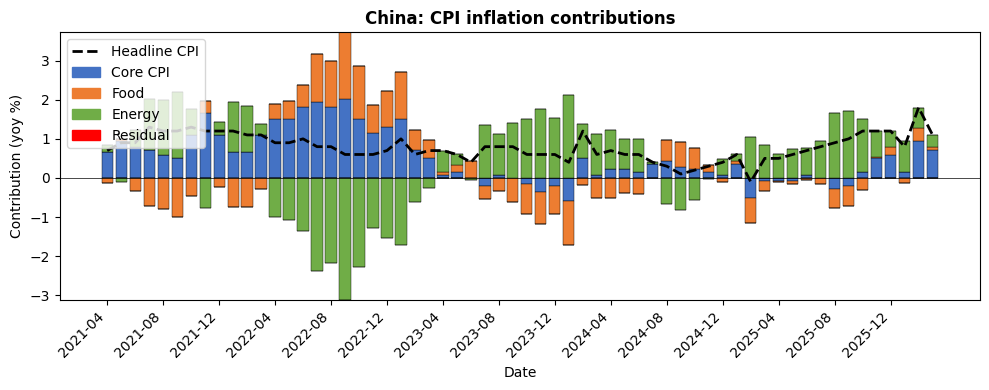

In [7]:
colors = {
    'core_contrib':   '#4472C4',
    'food_contrib':   '#ED7D31',
    'energy_contrib': '#70AD47',
    'residual':       '#FF0000'
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(plt_data)), plt_data['headline'], ls='dashed', c='k', lw=2, zorder=5)

bottom_pos = pd.Series(0.0, index=plt_data.index)
bottom_neg = pd.Series(0.0, index=plt_data.index)

for col, color in colors.items():
    vals = plt_data[col]
    pos = vals.clip(lower=0)
    neg = vals.clip(upper=0)
    ax.bar(range(len(plt_data)), pos, bottom=bottom_pos, color=color, edgecolor='k', linewidth=0.3, width=0.8)
    ax.bar(range(len(plt_data)), neg, bottom=bottom_neg, color=color, edgecolor='k', linewidth=0.3, width=0.8)
    bottom_pos += pos
    bottom_neg += neg

legend_handles = [
    plt.Line2D([0], [0], color='k', lw=2, ls='dashed', label='Headline CPI'),
    mpatches.Patch(color='#4472C4', label='Core CPI'),
    mpatches.Patch(color='#ED7D31', label='Food'),
    mpatches.Patch(color='#70AD47', label='Energy'),
    mpatches.Patch(color='#FF0000', label='Residual'),
]
ax.legend(handles=legend_handles, frameon=True, loc='upper left')

tick_positions = range(0, len(plt_data), 4)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([plt_data.index[i] for i in tick_positions], rotation=45, ha='right')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel('Contribution (yoy %)')
ax.set_xlabel('Date')
ax.set_title('China: CPI inflation contributions', fontweight='bold')
plt.tight_layout()
plt.savefig('CHN_CPI_contributions.jpeg', dpi=150, format='jpeg', bbox_inches='tight')
plt.show()

---

### Use case 2: Japan GDP expenditure decomposition

**Step 1: Check series availability**

The Japan GDP chart requires pre-computed contribution series from Haver. These are already expressed as contributions to QoQ annualized GDP growth in percentage points, so no weighting is needed.

In [8]:
japan_needed = ['jsapgpc@japan', 'jsacct@japan', 'jsacgct@japan', 'jsafct@japan', 'jsaxnct@japan']
for code in japan_needed:
    if code in meta.index:
        print(f'HAVE:    {code}  {meta.loc[code, "descriptor"]}')
    else:
        print(f'MISSING: {code}')

HAVE:    jsapgpc@japan  Japan: Contributions to Chg in Real GDP: GDP Expenditure Approach (SAAR, %)
HAVE:    jsacct@japan  Japan: Contributions to Chg in Real GDP: Private Consumption (SAAR, %)
HAVE:    jsacgct@japan  Japan: Contributions to Chg in Real GDP: Government Consumption (SAAR, %)
HAVE:    jsafct@japan  Japan: Contributions to Chg in Real GDP: Gross Fixed Capital Formation (SAAR, %)
HAVE:    jsaxnct@japan  Japan: Contributions to Chg in Real GDP: Net Exports of Goods & Svcs (SAAR, %)


These series were not in the repo initially. They were added using `manage.py`:

```powershell
python src/manage.py add jsapgpc@japan quarterly
python src/manage.py add jsacct@japan quarterly
python src/manage.py add jsacgct@japan quarterly
python src/manage.py add jsafct@japan quarterly
python src/manage.py add jsaxnct@japan quarterly

$env:PATH += ";D:\Apps\Git\bin"
git add config/series.yaml
git commit -m "Add Japan GDP expenditure contribution series"
git push
```

Then triggered a manual pull from Command Prompt:

```
D:\Apps\haver_launcher.bat
```

**Step 2: Load data**

No transformation needed — Haver provides these directly as contributions to GDP growth.

In [9]:
raw_gdp = load_multiple([
    'jsapgpc@japan',   # GDP QoQAR
    'jsacct@japan',    # Private consumption contribution
    'jsacgct@japan',   # Government consumption contribution
    'jsafct@japan',    # Capital formation contribution
    'jsaxnct@japan'    # Net exports contribution
], start='2015-01-01').dropna()
raw_gdp.columns = ['gdp', 'consumption', 'gov_consumption', 'capex', 'net_exports']

**Step 3: Plot**

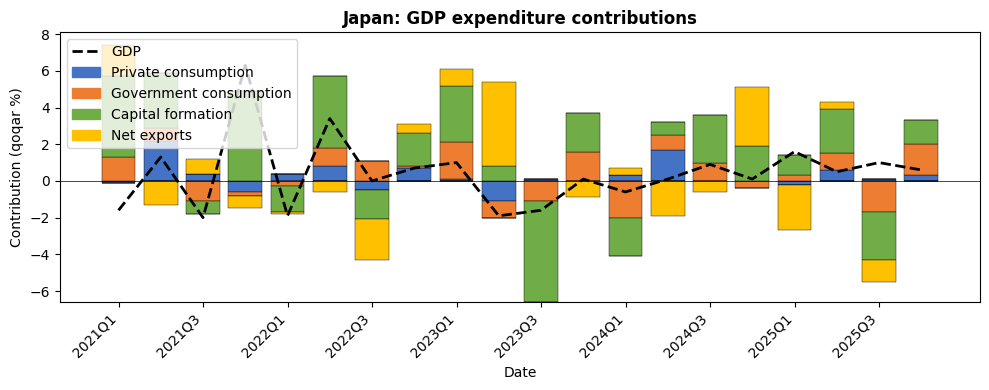

In [10]:
plt_gdp = raw_gdp.iloc[-20:].copy()
plt_gdp.index = plt_gdp.index.strftime('%YQ') + plt_gdp.index.quarter.astype(str)

colors_gdp = {
    'consumption':     '#4472C4',
    'gov_consumption': '#ED7D31',
    'capex':           '#70AD47',
    'net_exports':     '#FFC000'
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(plt_gdp)), plt_gdp['gdp'], ls='dashed', c='k', lw=2, zorder=5)

bottom_pos = pd.Series(0.0, index=plt_gdp.index)
bottom_neg = pd.Series(0.0, index=plt_gdp.index)

for col, color in colors_gdp.items():
    vals = plt_gdp[col]
    pos = vals.clip(lower=0)
    neg = vals.clip(upper=0)
    ax.bar(range(len(plt_gdp)), pos, bottom=bottom_pos, color=color, edgecolor='k', linewidth=0.3, width=0.8)
    ax.bar(range(len(plt_gdp)), neg, bottom=bottom_neg, color=color, edgecolor='k', linewidth=0.3, width=0.8)
    bottom_pos += pos
    bottom_neg += neg

legend_handles = [
    plt.Line2D([0], [0], color='k', lw=2, ls='dashed', label='GDP'),
    mpatches.Patch(color='#4472C4', label='Private consumption'),
    mpatches.Patch(color='#ED7D31', label='Government consumption'),
    mpatches.Patch(color='#70AD47', label='Capital formation'),
    mpatches.Patch(color='#FFC000', label='Net exports'),
]
ax.legend(handles=legend_handles, frameon=True, loc='upper left')

tick_positions = range(0, len(plt_gdp), 2)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([plt_gdp.index[i] for i in tick_positions], rotation=45, ha='right')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel('Contribution (qoqar %)')
ax.set_xlabel('Date')
ax.set_title('Japan: GDP expenditure contributions', fontweight='bold')
plt.tight_layout()
plt.savefig('JPN_GDP_contributions.jpeg', dpi=150, format='jpeg', bbox_inches='tight')
plt.show()